<a href="https://colab.research.google.com/github/dbstj118/2026_2-1_BDA/blob/main/10w_data_vis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install koreanize_matplotlib
import koreanize_matplotlib
%config inlineBackend.figure_format = 'retina'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 39.2 MB/s eta 0:00:00


In [2]:
!pip install pydataset

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 35.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pydataset: filename=pydataset-0.2.0-py3-none-any.whl size=15939415 sha256=1c317e47d538c786bf909f3d1103c5253cd3e3ab91bed8fa2c7e2e11788b8297
  Stored in directory: /root/.cache/pip/wheels/4c/82/ad/f04abc617222b10438b1285ab9b5cfaecd180c10a7c81cff54
Successfully built pydataset


###붓꽃 데이터 iris

In [3]:
from pydataset import data
iris = data('iris')
iris.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150 entries, 1 to 150
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sepal.Length  150 non-null    float64
 1   Sepal.Width   150 non-null    float64
 2   Petal.Length  150 non-null    float64
 3   Petal.Width   150 non-null    float64
 4   Species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 7.0+ KB


In [4]:
iris.describe()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
iris.describe(include='all')

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
count,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.843333,3.057333,3.758000,1.199333,NaN
std,0.828066,0.435866,1.765298,0.762238,NaN
min,4.300000,2.000000,1.000000,0.100000,NaN
25%,5.100000,2.800000,1.600000,0.300000,NaN
50%,5.800000,3.000000,4.350000,1.300000,NaN
75%,6.400000,3.300000,5.100000,1.800000,NaN


In [6]:
iris.Species.unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [7]:
iris.Species.value_counts()

,count
Species,
setosa,50
versicolor,50
virginica,50


In [8]:
from IPython.display import display_html
def display_side_by_side(*args):
    """여러 데이터프레임 비교가 쉽게 옆쪽으로 표시한다"""
    html_str=''
    for df in args:
        html_str += df.to_html() + '&nbsp;'*4
    display_html(html_str.replace('table','table style="display:inline"'), raw=True)

In [9]:
from IPython.display import display_html

def display_series_side_by_side(*args, names=None):
    """여러 Series를 옆으로 나란히 표시한다.

    Parameters
    ----------
    *args   : pd.Series 객체들
    names   : 각 Series의 제목 리스트 (생략 시 Series.name 사용)
    """
    html_str = ''
    for i, s in enumerate(args):
        # 제목 결정: names 인자 > Series.name > 인덱스 번호
        if names and i < len(names):
            title = names[i]
        elif s.name is not None:
            title = s.name
        else:
            title = f'Series {i}'

        table_html = s.to_frame(name=title).to_html()
        html_str += table_html + '&nbsp;' * 4

    display_html(
        html_str.replace('table', 'table style="display:inline; vertical-align:top"'),
        raw=True
    )

In [10]:
display_side_by_side(iris.head(),iris.tail())

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
1,5.1,3.5,1.4,0.2,setosa
2,4.9,3.0,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,4.6,3.1,1.5,0.2,setosa
5,5.0,3.6,1.4,0.2,setosa
,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
146,6.7,3.0,5.2,2.3,virginica
147,6.3,2.5,5.0,1.9,virginica
148,6.5,3.0,5.2,2.0,virginica
149,6.2,3.4,5.4,2.3,virginica


In [13]:
display_series_side_by_side(iris['Petal.Length'][:5],iris.Species.value_counts())

,Petal.Length
1,1.4
2,1.4
3,1.3
4,1.5
5,1.4
,count
Species,
setosa,50
versicolor,50
virginica,50


In [15]:
display_side_by_side(iris['Petal.Length'][:5].to_frame(),iris.Species.value_counts().to_frame())

,Petal.Length
1,1.4
2,1.4
3,1.3
4,1.5
5,1.4
,count
Species,
setosa,50
versicolor,50
virginica,50


[ 4.  5.  7. 16.  9.  5. 13. 14. 10.  6. 10. 16.  7. 11.  4.  2.  4.  1.
  5.  1.]
[4.3  4.48 4.66 4.84 5.02 5.2  5.38 5.56 5.74 5.92 6.1  6.28 6.46 6.64
 6.82 7.   7.18 7.36 7.54 7.72 7.9 ]
<BarContainer object of 20 artists>


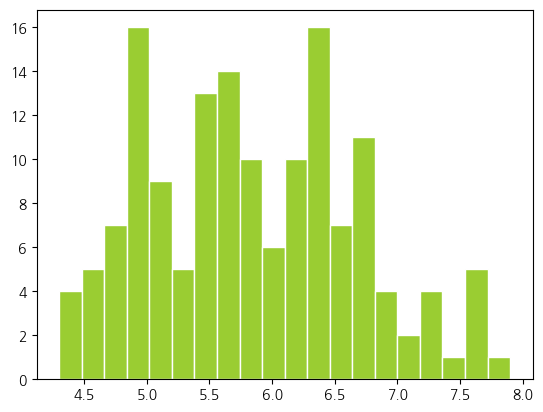

In [17]:
import matplotlib.pyplot as plt
n,bins,patches = plt.hist(iris['Sepal.Length'],bins = 20, color='yellowgreen',edgecolor='white')
print(n)
print(bins)
print(patches)

###값에 따라 막대의 색상을 수정

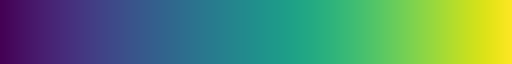

In [37]:
plt.cm.viridis

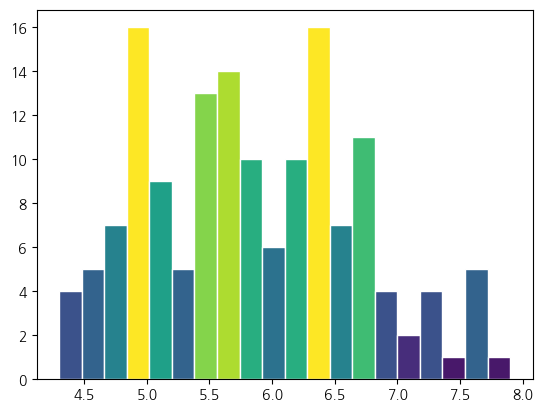

In [34]:
import matplotlib.pyplot as plt
n,bins,patches = plt.hist(iris['Sepal.Length'],bins = 20, color='yellowgreen',edgecolor='white')
for i in range(len(patches)):
  patches[i].set_facecolor(plt.cm.viridis(n[i]/max(n)))
plt.show()

###커널 밀도 추정 선 그리기

<Axes: ylabel='Density'>

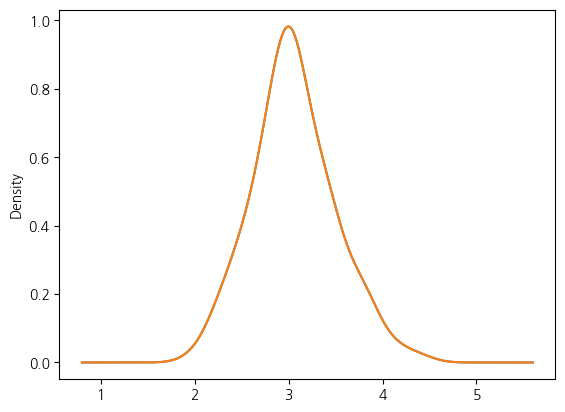

In [21]:
iris['Sepal.Width'].plot.density()
iris['Sepal.Width'].plot.kde()

###seaborn의 함수 sns.histplot()과 sns.rugplot()

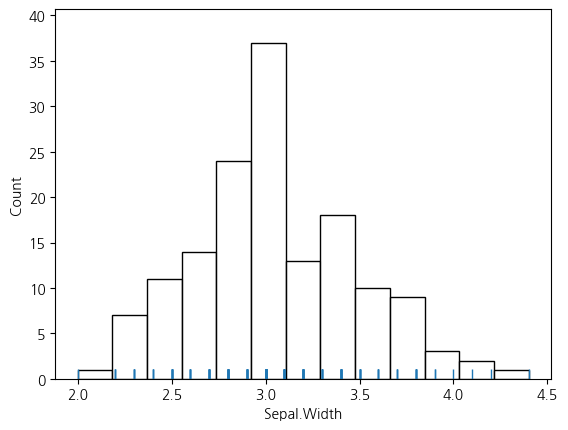

In [24]:
import seaborn as sns

sns.histplot(data=iris, x=iris['Sepal.Width'],color='white')
sns.rugplot(data=iris, x = iris['Sepal.Width']);

###hue='Species'

<Axes: xlabel='Sepal.Width', ylabel='Count'>

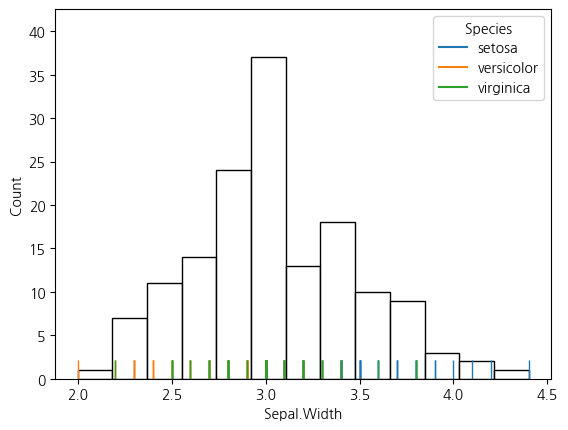

In [26]:
sns.histplot(data=iris, x=iris['Sepal.Width'],color='white')
sns.rugplot(data = iris, x = iris['Sepal.Width'],height=0.05,hue='Species')

###sns.displot(data = iris, x = iris['Sepal.Width'], kde=True, rug=True)

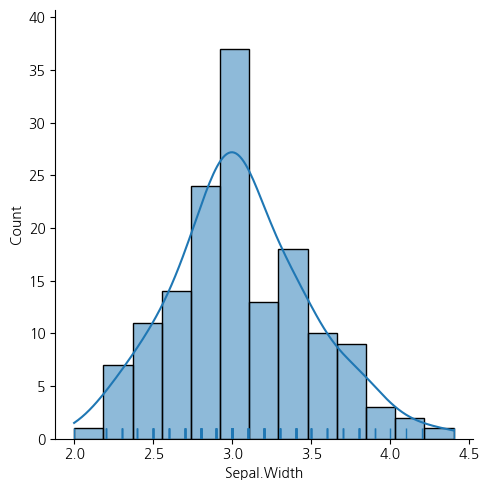

In [30]:
import seaborn as sns
sns.displot(data=iris, x=iris['Sepal.Width'],kde=True,rug=True)

###sns.displot(data = iris, x = iris['Sepal.Width'], col="Species", …)

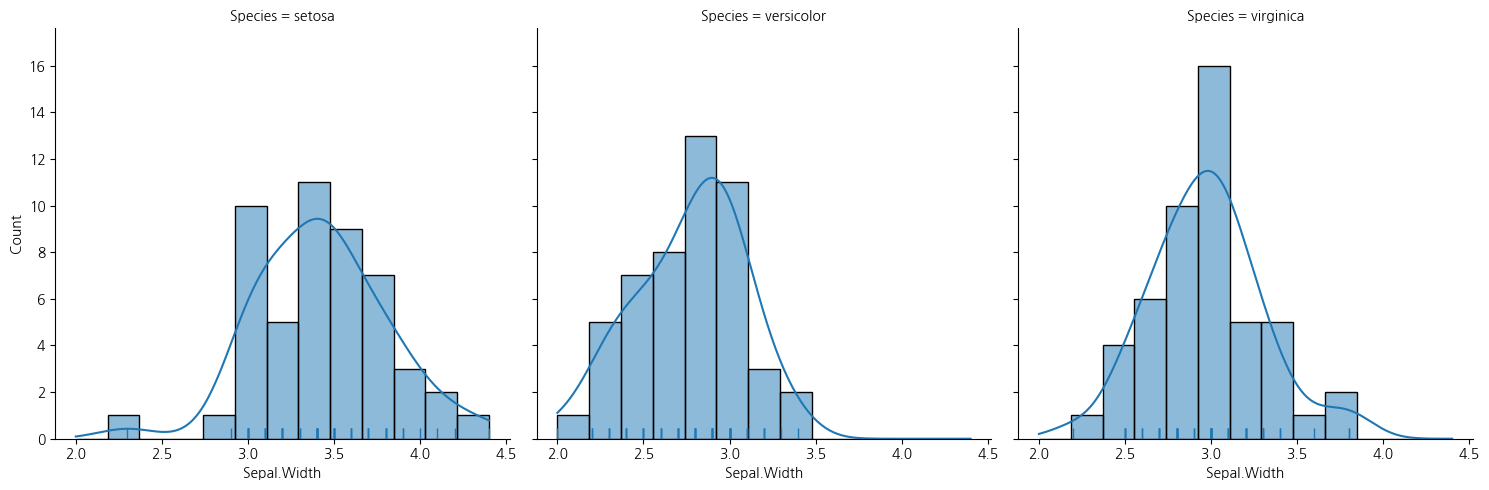

In [38]:
sns.displot(data = iris, x = iris['Sepal.Width'], col="Species",kde=True,rug=True)

###sns.displot(data = iris, x = iris['Sepal.Width'], kde=True, rug=True,multiple="stack", hue="Species")

겹치지 않게 하려면 multiple="stack"

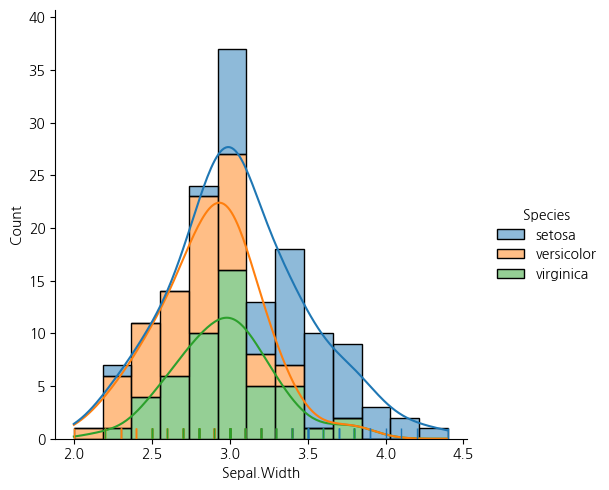

In [40]:
sns.displot(data = iris, x = iris['Sepal.Width'], kde=True, rug=True,
multiple="stack", hue="Species")

###pie() 활용 파이 차트

([<matplotlib.patches.Wedge at 0x7a11c6140470>,
 [Text(1.0461621649530053, 0.3399187029582827, 'Oranges'),
  Text(0.33991865722907993, 1.0461621798113232, 'Apples'),
  Text(-1.046162235191088, 0.33991848678762215, 'Bananas'),
  Text(0.33991884014588697, -1.0461621203780394, 'Cherries')])

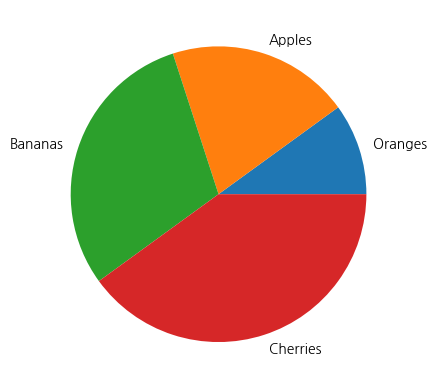

In [41]:
fruits = ["Oranges","Apples","Bananas","Cherries"]
plt.pie([10,20,30,40],labels=fruits)

인자 autopct='%.1f%%' 백분율로 비율을 표시

In [43]:
from pydataset import data
mtc = data('mtcars')
mtc.cyl.value_counts().sort_index()

,count
cyl,
4,11
6,7
8,14


In [44]:
mtc.cyl.value_counts().sort_index().index

Index([4, 6, 8], dtype='int64', name='cyl')

In [46]:
txt = [str(i)+'기통' for i in mtc.cyl.value_counts().sort_index().index]
txt

['4기통', '6기통', '8기통']

Text(0.5, 1.0, '기통 수에 따른 자동차 비율')

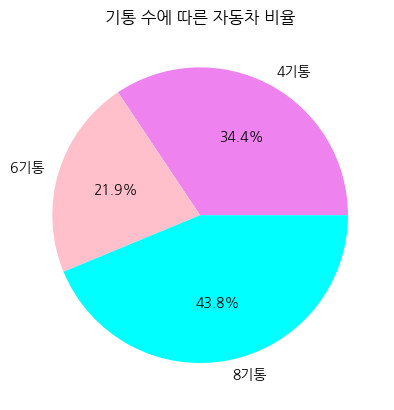

In [47]:
plt.pie(mtc.cyl.value_counts().sort_index(),
colors = ["violet", "pink", "aqua"],
autopct='%.1f%%', labels = txt)
plt.title("기통 수에 따른 자동차 비율")

In [48]:
mtc.gear.value_counts().sort_index()

,count
gear,
3,15
4,12
5,5


In [49]:
labels = [str(i) + '기어' for i in mtc.gear.value_counts().sort_index().index]
labels

['3기어', '4기어', '5기어']

In [51]:
##라벨의 개수만큼 색상 리스트 생성
colors = sns.color_palette('Accent',len(labels))
colors

[(0.4980392156862745, 0.788235294117647, 0.4980392156862745),
 (0.7450980392156863, 0.6823529411764706, 0.8313725490196079),
 (0.9921568627450981, 0.7529411764705882, 0.5254901960784314)]

In [52]:
##라벨의 개수만큼 색상 리스트 생성
colors = sns.color_palette('Set1',len(labels))
colors

[(0.8941176470588236, 0.10196078431372549, 0.10980392156862745),
 (0.21568627450980393, 0.49411764705882355, 0.7215686274509804),
 (0.30196078431372547, 0.6862745098039216, 0.2901960784313726)]

In [54]:
colors = sns.color_palette('Set2',7)
colors

[(0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
 (0.9058823529411765, 0.5411764705882353, 0.7647058823529411),
 (0.6509803921568628, 0.8470588235294118, 0.32941176470588235),
 (1.0, 0.8509803921568627, 0.1843137254901961),
 (0.8980392156862745, 0.7686274509803922, 0.5803921568627451)]

shadow. startangle

Text(0.5, 1.0, '기어 수에 따른 자동차 비율')

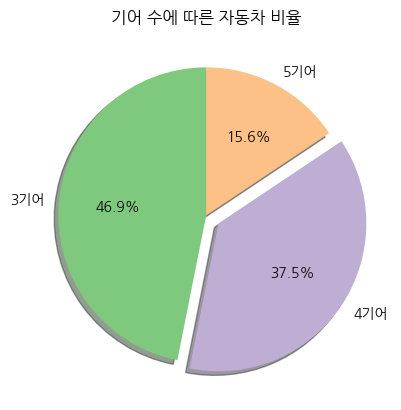

In [56]:
colors = sns.color_palette('Accent',len(txt)) ## 라벨의 개수 만큼 색상 리스트 생성
plt.pie(mtc.gear.value_counts().sort_index(), colors=colors, explode=[0, .1, 0],
shadow = True, startangle = 90, autopct='%.1f%%', labels = labels)
plt.title("기어 수에 따른 자동차 비율")

##3. 바이올린과 상관관계 시각화

{'bodies': [<matplotlib.collections.FillBetweenPolyCollection at 0x7a11c65ddf40>],
 'cmaxes': <matplotlib.collections.LineCollection at 0x7a11c6149b50>,
 'cmins': <matplotlib.collections.LineCollection at 0x7a11c614af30>,
 'cbars': <matplotlib.collections.LineCollection at 0x7a11c614a240>}

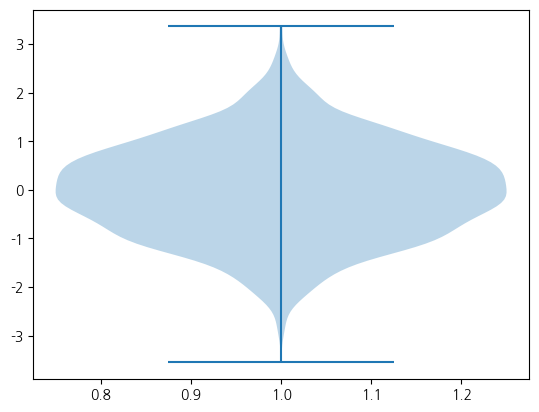

In [62]:
import numpy as np
data = np.random.randn(2000)
plt.violinplot(data)

{'bodies': [<matplotlib.collections.FillBetweenPolyCollection at 0x7a11d71e44d0>],
 'cmaxes': <matplotlib.collections.LineCollection at 0x7a11c6a56cf0>,
 'cmins': <matplotlib.collections.LineCollection at 0x7a11c67033e0>,
 'cbars': <matplotlib.collections.LineCollection at 0x7a11c6a57410>,
 'cquantiles': <matplotlib.collections.LineCollection at 0x7a11c66ccf50>}

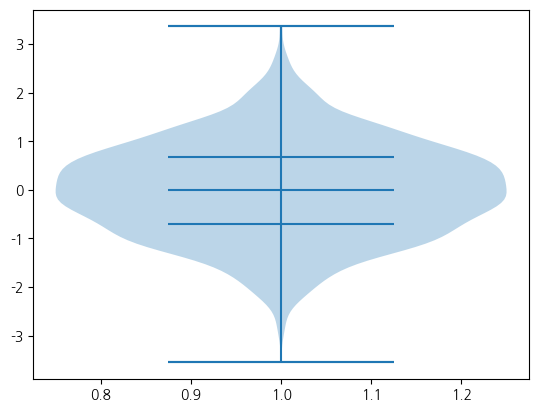

In [63]:
plt.violinplot(data, quantiles=[0,.25,.5,.75,1])

{'bodies': [<matplotlib.collections.FillBetweenPolyCollection at 0x7a11c64466c0>],
 'cmaxes': <matplotlib.collections.LineCollection at 0x7a11c64e28a0>,
 'cmins': <matplotlib.collections.LineCollection at 0x7a11d74cc5f0>,
 'cbars': <matplotlib.collections.LineCollection at 0x7a11c61431a0>,
 'cquantiles': <matplotlib.collections.LineCollection at 0x7a11c6748da0>}

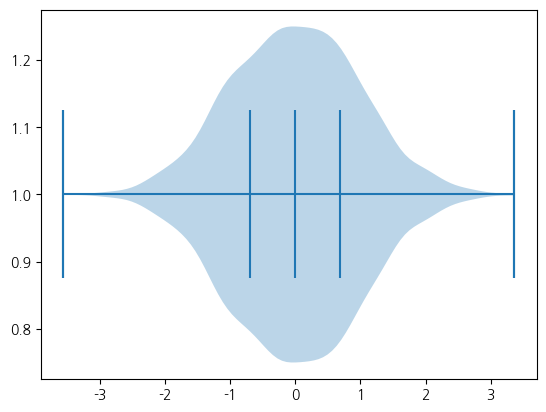

In [65]:
plt.violinplot(data, quantiles=[0,.25,.5,.75,1], vert=False)

stripplot 이미 그린 바이올린 플롯에 데이터 분포를 추가

<Axes: >

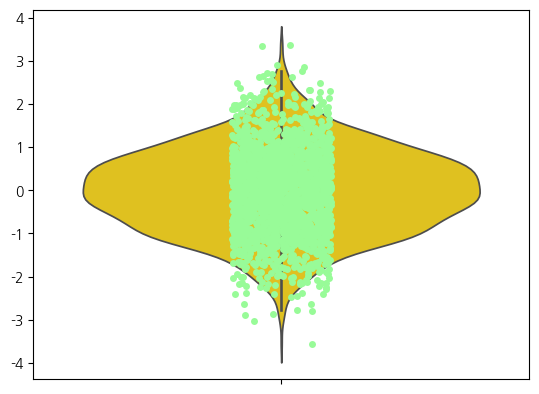

In [67]:
import seaborn as sns
sns.violinplot(data, color='gold')
sns.stripplot(data, color='palegreen')

<Axes: xlabel='Species', ylabel='Sepal.Length'>

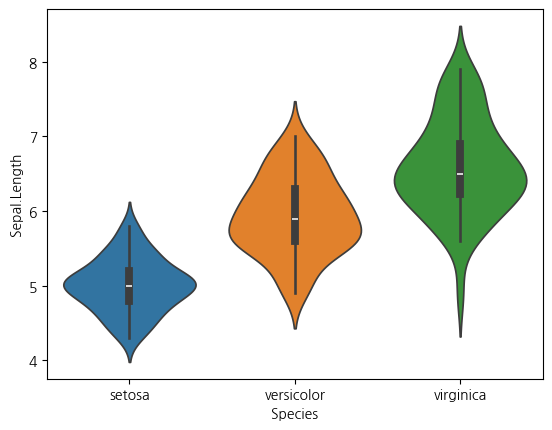

In [68]:
from pydataset import data
iris = data('iris')

import seaborn as sns
sns.violinplot(iris, x = 'Species',y='Sepal.Length',hue='Species')

<Axes: xlabel='Species', ylabel='Sepal.Length'>

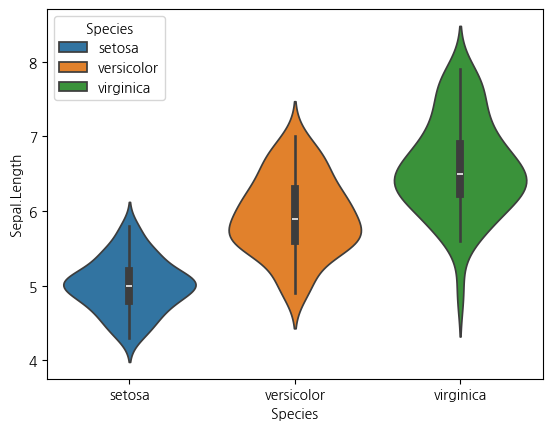

In [69]:
sns.violinplot(iris, x='Species', y='Sepal.Length', hue='Species', legend='full')

###sns.pairplot()

In [70]:
from pydataset import data
mtc = data('mtcars')
mtc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, Mazda RX4 to Volvo 142E
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mpg     32 non-null     float64
 1   cyl     32 non-null     int64  
 2   disp    32 non-null     float64
 3   hp      32 non-null     int64  
 4   drat    32 non-null     float64
 5   wt      32 non-null     float64
 6   qsec    32 non-null     float64
 7   vs      32 non-null     int64  
 8   am      32 non-null     int64  
 9   gear    32 non-null     int64  
 10  carb    32 non-null     int64  
dtypes: float64(5), int64(6)
memory usage: 3.0+ KB


In [71]:
mincars = mtc.iloc[:,:4]
mincars.head()

,mpg,cyl,disp,hp
Mazda RX4,21.0,6,160.0,110
Mazda RX4 Wag,21.0,6,160.0,110
Datsun 710,22.8,4,108.0,93
Hornet 4 Drive,21.4,6,258.0,110
Hornet Sportabout,18.7,8,360.0,175


In [72]:
print(mtc.columns[:4])
print(mtc.columns[:4].to_list())

Index(['mpg', 'cyl', 'disp', 'hp'], dtype='object')
['mpg', 'cyl', 'disp', 'hp']


In [73]:
mincars = mtc[mtc.columns[:4].to_list()]
mincars.head(3)

,mpg,cyl,disp,hp
Mazda RX4,21.0,6,160.0,110
Mazda RX4 Wag,21.0,6,160.0,110
Datsun 710,22.8,4,108.0,93


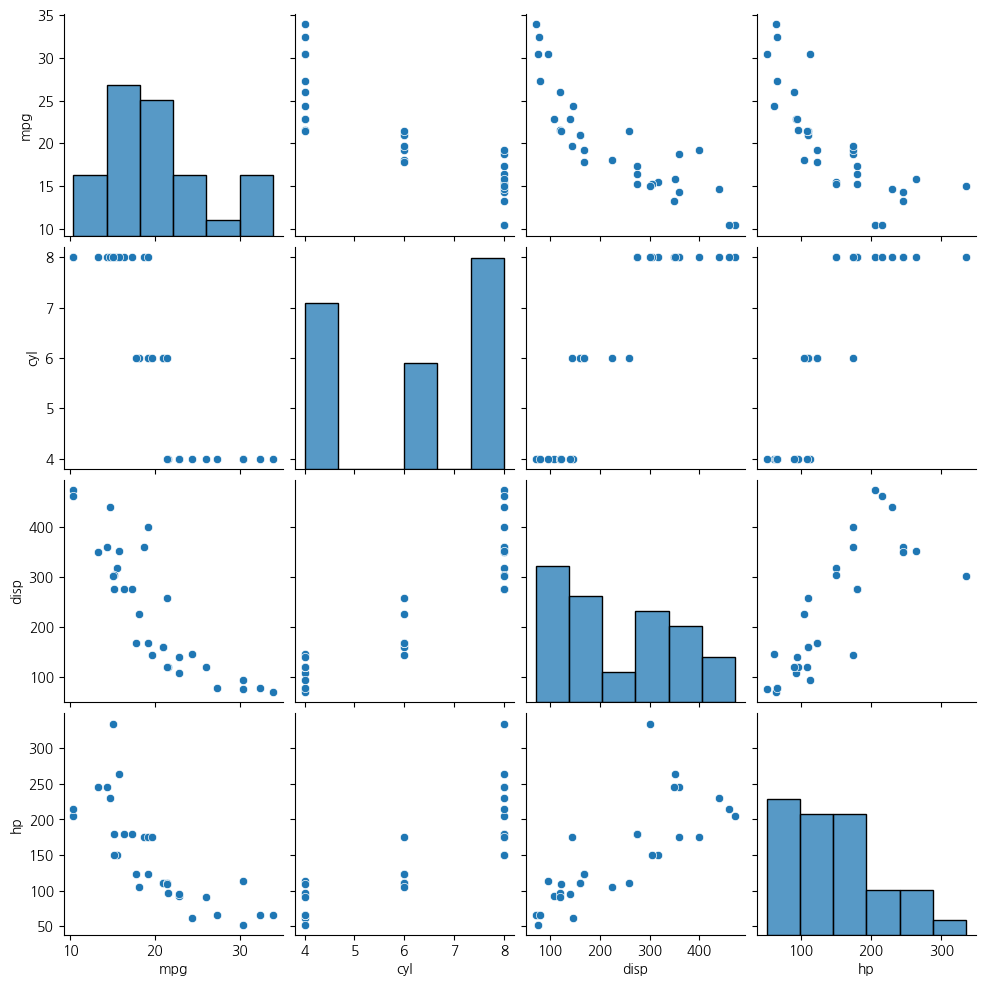

In [74]:
sns.pairplot(mincars)

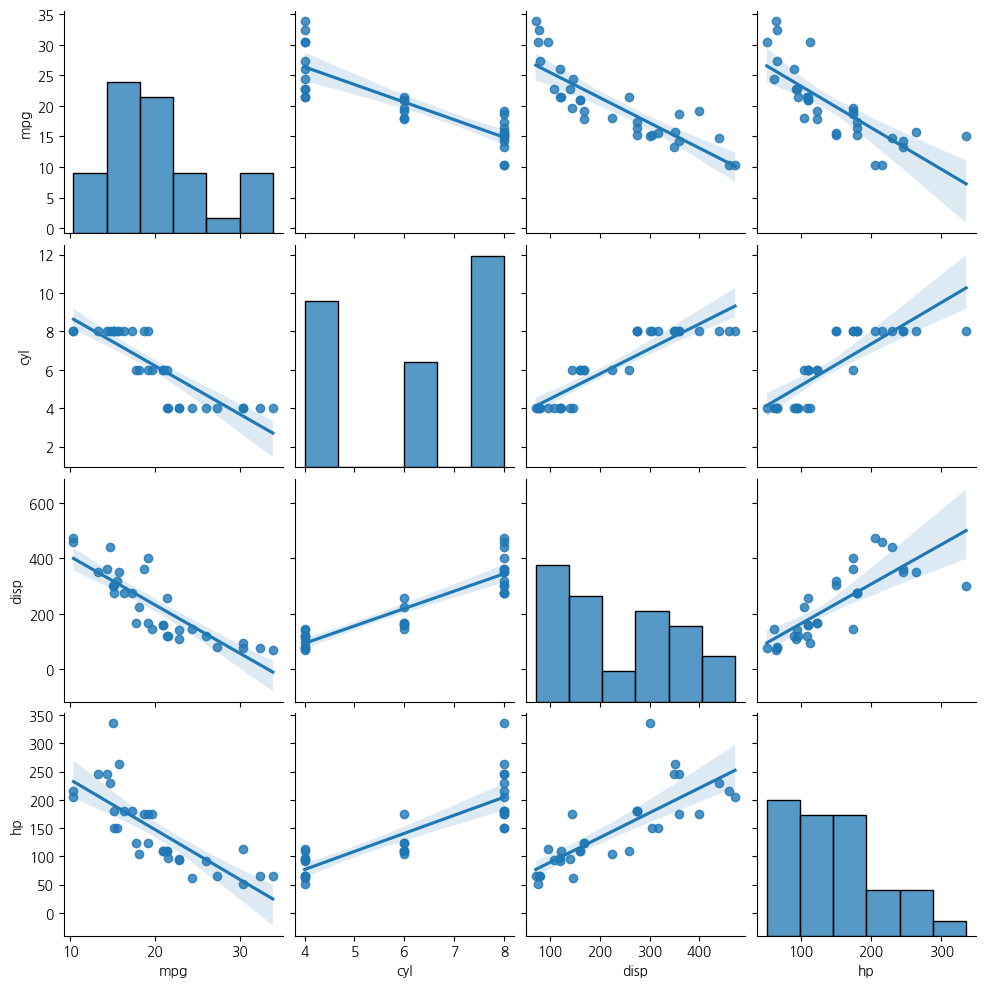

In [75]:
sns.pairplot(mincars,kind='reg')

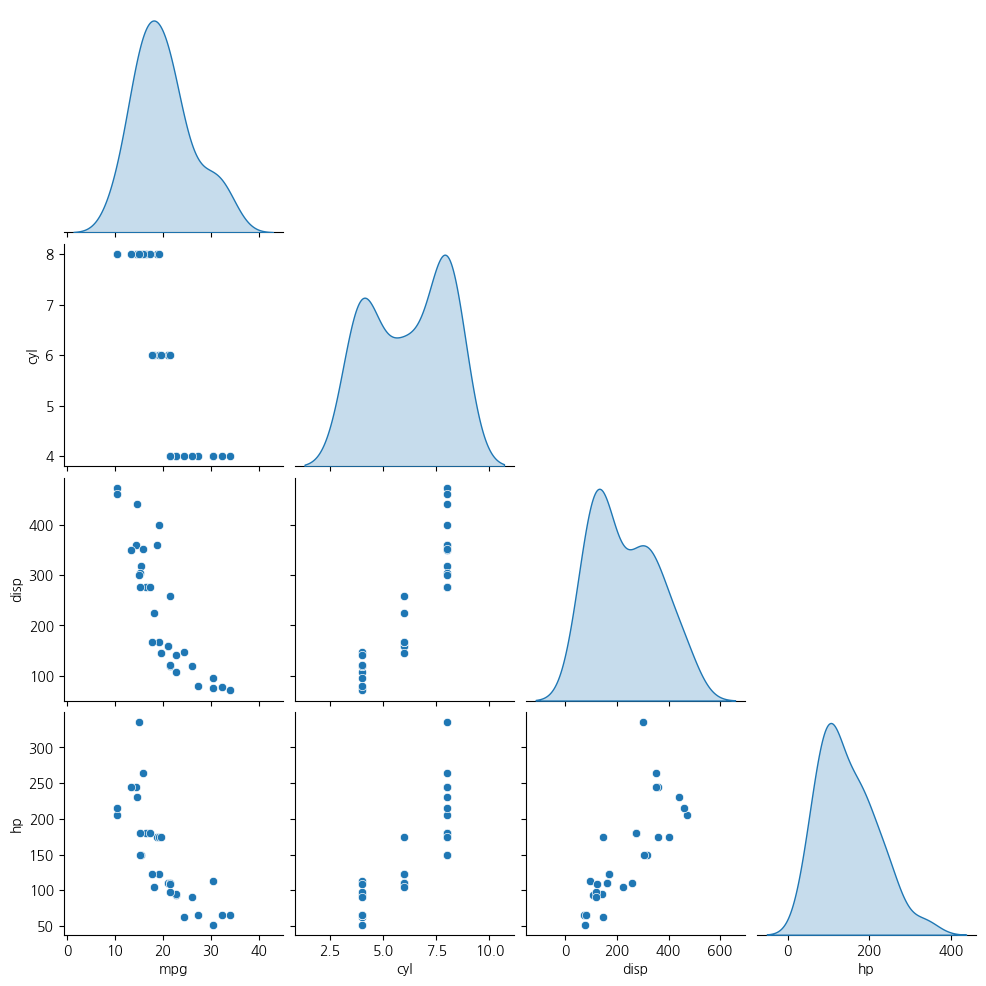

In [76]:
sns.pairplot(mincars, diag_kind='kde',corner=True)

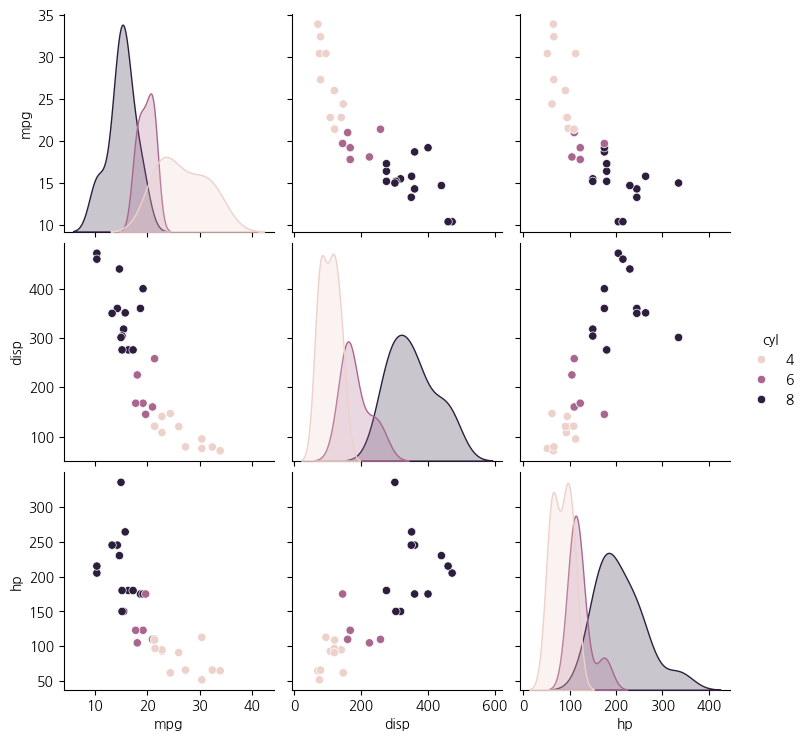

In [93]:
sns.pairplot(mincars, hue='cyl')

##상관계수   
0에 근접할수록 선형 관계가 약해짐  
양수 값은 양의 상관관계. 음수 값은 음의 상관관계

###붓꽃 데이터 iris

In [57]:
import seaborn as sns
iris = sns.load_dataset("iris")
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [58]:
import pandas as pd
pd.set_option('display.precision',2)

In [59]:
corr = iris[iris.columns[:-1].to_list()].corr()
corr

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.00,-0.12,0.87,0.82
sepal_width,-0.12,1.00,-0.43,-0.37
petal_length,0.87,-0.43,1.00,0.96
petal_width,0.82,-0.37,0.96,1.00


<Axes: >

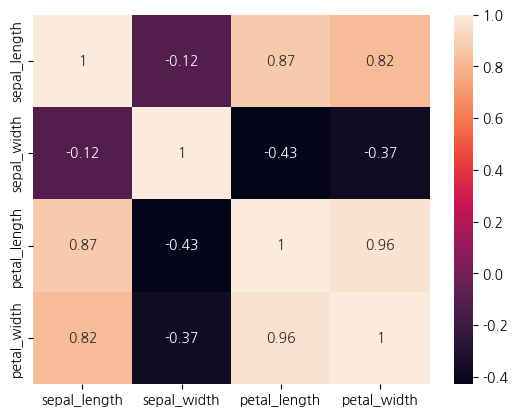

In [60]:
sns.heatmap(corr, annot=True)

<Axes: >

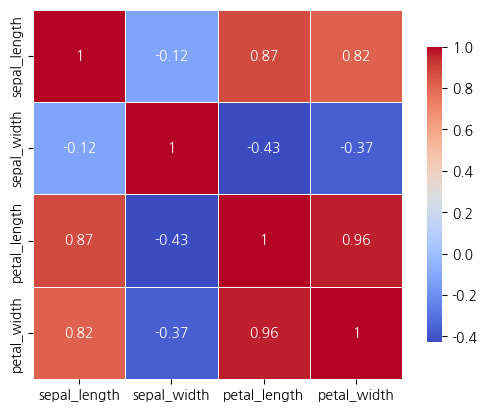

In [77]:
sns.heatmap(corr,
            annot=True,  #숫지 표시
            cmap='coolwarm',  #색상 팔레트
            square=True,  #정사각형 셀
            linewidths=0.5,  #셀 테두리
            cbar_kws={'shrink':0.8})  #컬러바 크기 조정

###mask

In [78]:
import numpy as np
mask = np.zeros_like(corr)
mask

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [79]:
np.triu_indices_from(mask)

(array([0, 0, 0, 0, 1, 1, 1, 2, 2, 3]), array([0, 1, 2, 3, 1, 2, 3, 2, 3, 3]))

In [84]:
# 오른쪽 위 대각 행렬을 1로 바꾸기
##mask[np.triu_indices_from(mask)] = 1
mask[np.triu_indices_from(mask)] = True
mask

array([[1., 1., 1., 1.],
       [0., 1., 1., 1.],
       [0., 0., 1., 1.],
       [0., 0., 0., 1.]])

In [83]:
# mask 첫 번째 행, 마지막 열 제거
mask_new = mask[1:,:-1]
mask_new

array([[0., 1., 1.],
       [0., 0., 1.],
       [0., 0., 0.]])

In [85]:
corr_iris_new = corr.iloc[1:,:-1]
corr_iris_new

,sepal_length,sepal_width,petal_length
sepal_width,-0.12,1.00,-0.43
petal_length,0.87,-0.43,1.00
petal_width,0.82,-0.37,0.96


<Axes: >

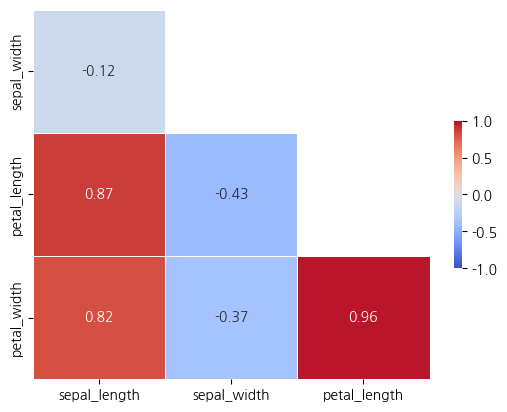

In [87]:
sns.heatmap(corr_iris_new, annot=True, cmap='coolwarm', mask=mask_new,
            annot_kws = {"size":10}, vmin=-1, vmax=1,
            cbar_kws = {'shrink':.4},  #범례 크기 줄이기
            linewidths=.5)  #경계 구분선 추가

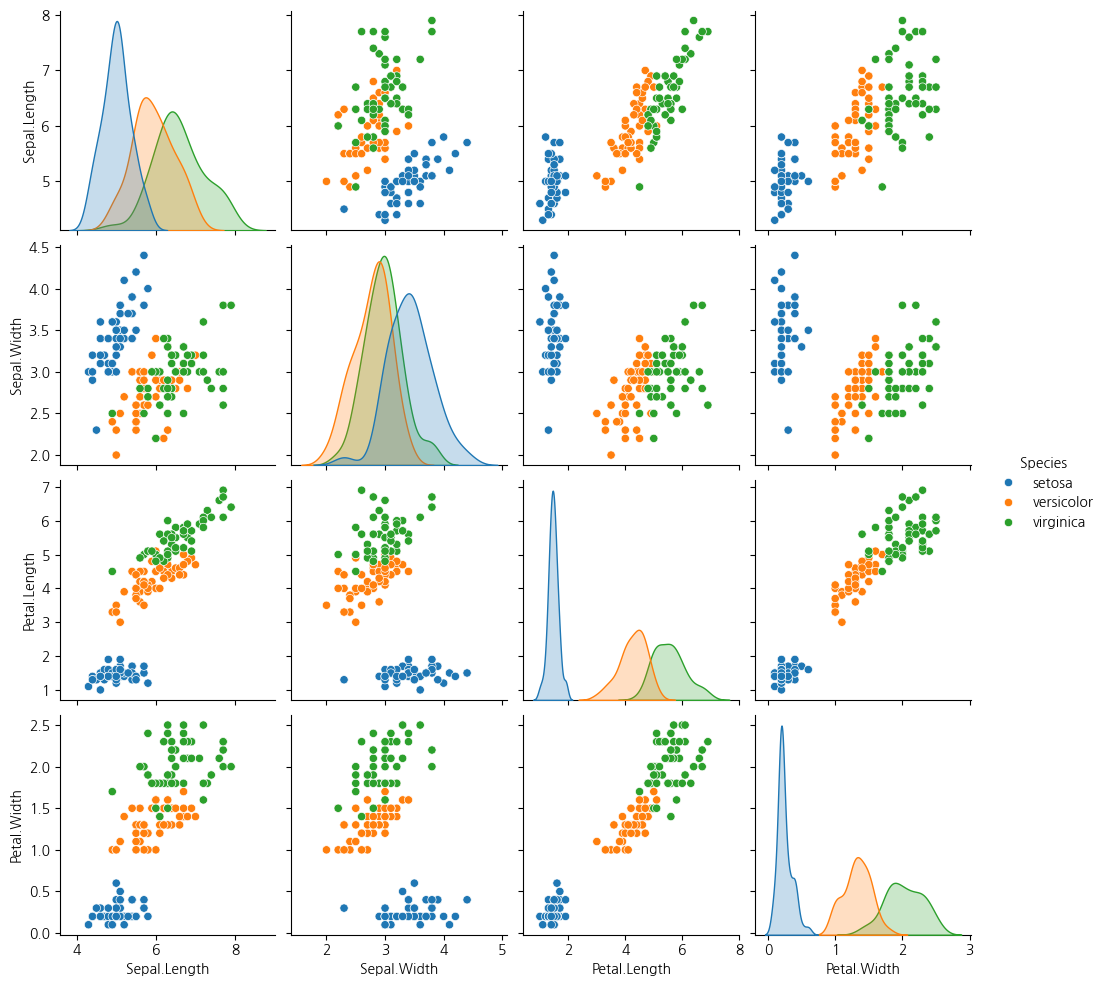

In [89]:
sns.pairplot(iris, hue='Species')

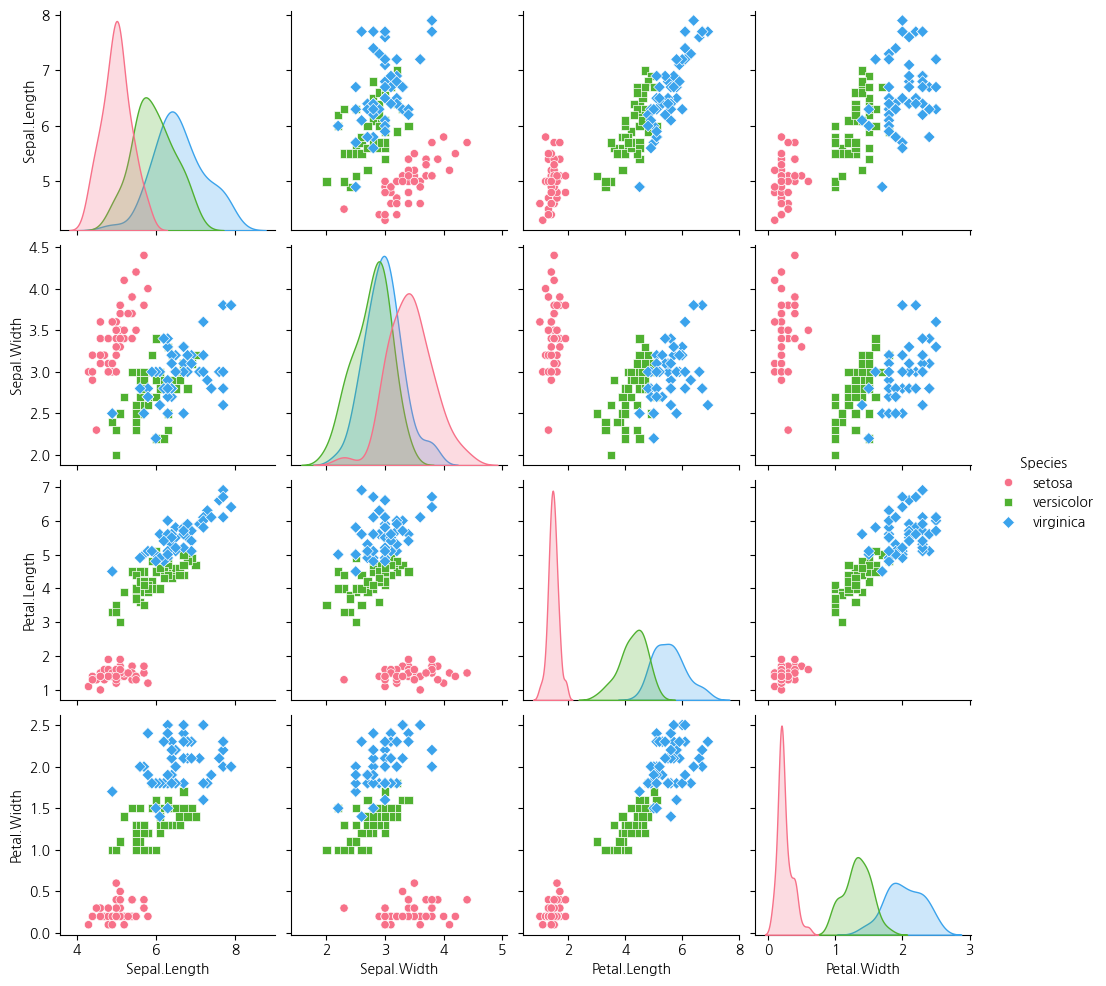

In [91]:
sns.pairplot(iris, hue="Species", palette="husl", markers=["o", "s", "D"])

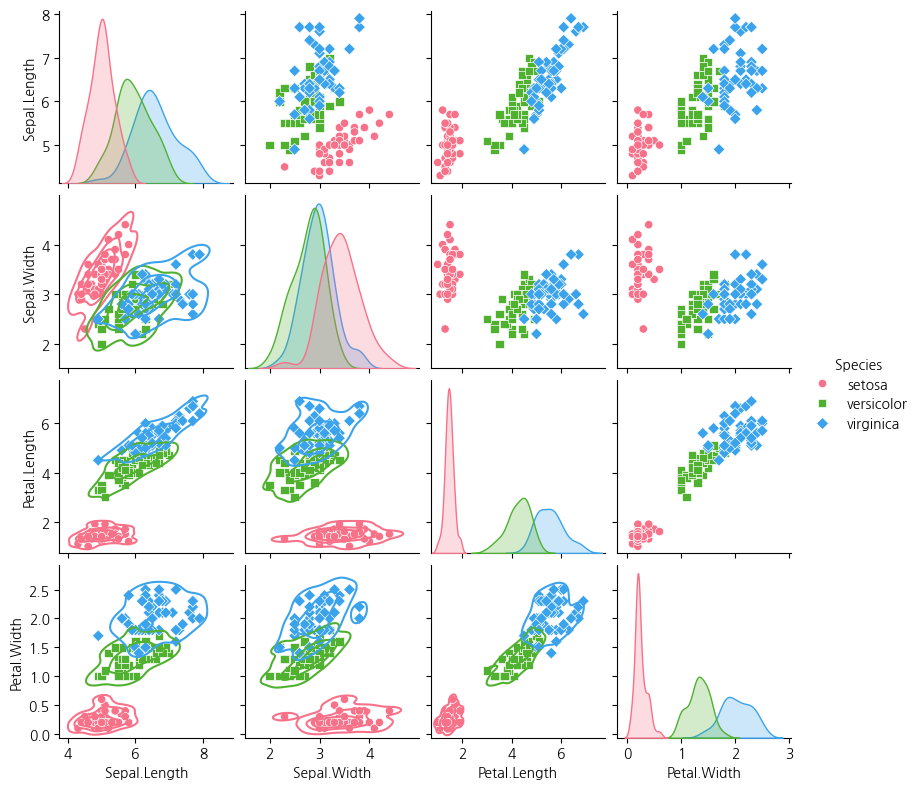

In [92]:
g = sns.pairplot(iris, hue="Species", palette="husl", height=2.0,markers=["o", "s", "D"])
g.map_lower(sns.kdeplot, levels=4,color=".2")